---
title: ENSO Index Visualization
description: Example workflow to visualize the El Niño Southern Oscillation using the NOAA Oceanic Niño Index
authors:
  - name: Jane Doe
    orcid: 0000-0000-0000-0000
---

## Load the Oceanic Niño Index from NOAA

The NOAA Climate Prediction Center (CPC) publishes the [Oceanic Niño Index (ONI)](https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php), a running 3-month mean sea surface temperature anomaly in the Niño 3.4 region (5°N-5°S, 120°-170°W). It is the standard index used to track El Niño and La Niña episodes. The data is published as a plain-text table and can be loaded directly from NOAA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

NOAA_ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"

oni = pd.read_csv(NOAA_ONI_URL, sep=r"\s+")
oni.head()

,SEAS,YR,TOTAL,ANOM
0,DJF,1950,24.72,-1.53
1,JFM,1950,25.17,-1.34
2,FMA,1950,25.75,-1.16
3,MAM,1950,26.12,-1.18
4,AMJ,1950,26.32,-1.07


## Build a Time Index

Each row represents a 3-month running season (e.g. `DJF` = December-January-February) rather than a calendar month. To plot the series over time, the `SEAS`/`YR` columns are converted into a single date column, using the middle month of each season.

In [2]:
season_to_month = {
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4, "AMJ": 5, "MJJ": 6,
    "JJA": 7, "JAS": 8, "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
}

oni["month"] = oni["SEAS"].map(season_to_month)
oni["date"] = pd.to_datetime(dict(year=oni["YR"], month=oni["month"], day=1))
oni = oni.sort_values("date").reset_index(drop=True)
oni[["date", "SEAS", "YR", "ANOM"]].head()

,date,SEAS,YR,ANOM
0,1950-01-01,DJF,1950,-1.53
1,1950-02-01,JFM,1950,-1.34
2,1950-03-01,FMA,1950,-1.16
3,1950-04-01,MAM,1950,-1.18
4,1950-05-01,AMJ,1950,-1.07


## Classify El Niño / La Niña Phases

By NOAA convention, an El Niño (warm) episode is associated with an ONI anomaly of +0.5°C or higher, and a La Niña (cool) episode with an anomaly of -0.5°C or lower, sustained for at least five consecutive overlapping seasons. Here we apply the simple threshold to each season for visualization purposes.

In [3]:
def classify(anom):
    if anom >= 0.5:
        return "El Niño"
    elif anom <= -0.5:
        return "La Niña"
    return "Neutral"


oni["phase"] = oni["ANOM"].apply(classify)
oni[["date", "ANOM", "phase"]].tail(12)

,date,ANOM,phase
905,2025-06-01,-0.04,Neutral
906,2025-07-01,-0.14,Neutral
907,2025-08-01,-0.28,Neutral
908,2025-09-01,-0.40,Neutral
909,2025-10-01,-0.51,La Niña
910,2025-11-01,-0.55,La Niña
911,2025-12-01,-0.54,La Niña
912,2026-01-01,-0.37,Neutral
913,2026-02-01,-0.14,Neutral
914,2026-03-01,0.13,Neutral


## Plot the ENSO Index

The chart below shows the ONI anomaly over time, colored by phase, with the ±0.5°C El Niño / La Niña thresholds marked.

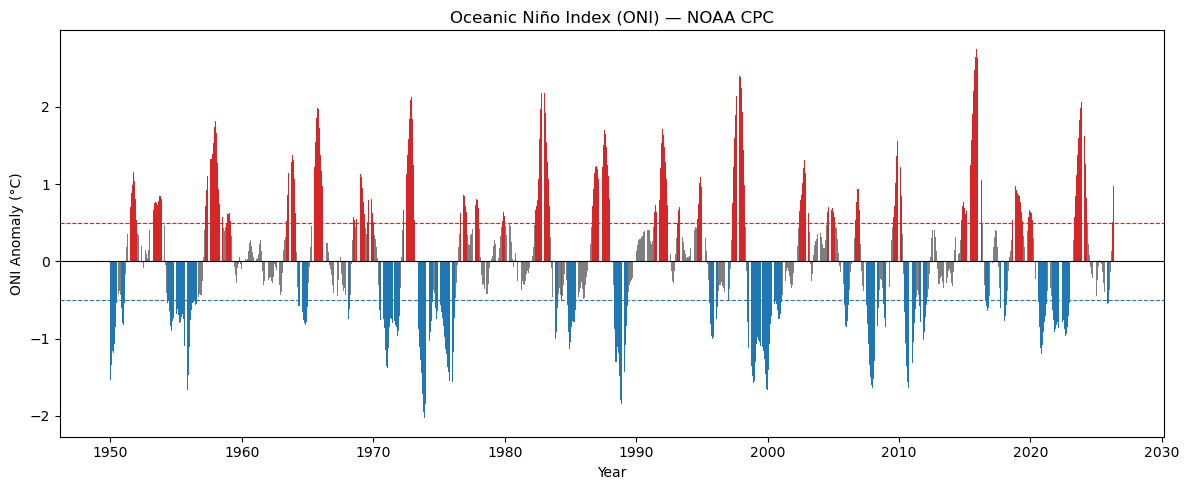

In [4]:
#| label: fig-enso
phase_colors = {"El Niño": "#d62728", "La Niña": "#1f77b4", "Neutral": "#7f7f7f"}
colors = oni["phase"].map(phase_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(oni["date"], oni["ANOM"], color=colors, width=25)
ax.axhline(0.5, color="#d62728", linestyle="--", linewidth=0.8)
ax.axhline(-0.5, color="#1f77b4", linestyle="--", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("ONI Anomaly (°C)")
ax.set_xlabel("Year")
ax.set_title("Oceanic Niño Index (ONI) — NOAA CPC")
fig.tight_layout()
plt.show()

## Most Recent Seasons

A quick look at the most recent classified seasons in the series.

In [5]:
oni[["date", "SEAS", "YR", "ANOM", "phase"]].tail(12).reset_index(drop=True)

,date,SEAS,YR,ANOM,phase
0,2025-06-01,MJJ,2025,-0.04,Neutral
1,2025-07-01,JJA,2025,-0.14,Neutral
2,2025-08-01,JAS,2025,-0.28,Neutral
3,2025-09-01,ASO,2025,-0.40,Neutral
4,2025-10-01,SON,2025,-0.51,La Niña
5,2025-11-01,OND,2025,-0.55,La Niña
6,2025-12-01,NDJ,2025,-0.54,La Niña
7,2026-01-01,DJF,2026,-0.37,Neutral
8,2026-02-01,JFM,2026,-0.14,Neutral
9,2026-03-01,FMA,2026,0.13,Neutral
